# Module 2 · Transformers — In-class Lab 
## Layer tricks, cost, and what the model is (and isn't) telling you

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mago-cinv/course-template/blob/master/modules/02-transformers/labs/in-class/lab-4-tricks.ipynb)

This is **Mini-lab 4**, the last of the three in-class mini-labs of this module — one per lesson,
each needing only its own lesson's theory. It pairs with **Lesson 4** (the tricks that make depth
trainable, the cost of attention and what the KV cache buys back, and interpretability).

### How this lab works

**The machinery is given to you.** LayerNorm, the residual wrapper (with a no-residual ablation),
closed-form cost/cache formulas, and a small self-attention pipeline wired for gradient saliency —
all written, documented and running.

**What you write is the investigation.** Three separate questions, three separate exercises: what do
LayerNorm and the residual connection actually buy (measured, not asserted)? What does attention's
quadratic cost really cost across a whole generation, and what does caching buy back? And — new this
pass — does high attention weight always mean the model actually relied on that token, or can the two
signals disagree?

Treat everything above each 🔬 section as your **sandbox**: read it, run it, then take it apart.

In [1]:
# Setup — run me first (works on Colab AND locally)
import sys

if "google.colab" in sys.modules:
    %pip install -q matplotlib numpy

print("Setup OK — running on", "Colab" if "google.colab" in sys.modules else "local Python")

Setup OK — running on local Python


In [2]:
# Imports + seeds
import math

import matplotlib.pyplot as plt
import numpy as np
import torch

torch.manual_seed(0)
np.random.seed(0)
torch.set_printoptions(precision=4, sci_mode=False)

print("torch", torch.__version__, "— CPU only, no downloads in this notebook")

torch 2.13.0+cpu — CPU only, no downloads in this notebook


## 1 · The layer toolkit (provided)

LayerNorm, the position-wise FFN, and a residual wrapper with **three** modes — `"pre"`, `"post"`
and `"none"` (the ablation Lesson 4 implies but never runs).

| function | what it does |
|---|---|
| `layer_norm(x, gamma=None, beta=None, eps=1e-5)` | equation (2): normalize each **token** over its feature axis, then scale/shift |
| `make_ffn(d_model, d_ff, seed)` | random weights for the two-layer position-wise FFN |
| `ffn(x, p)` | equation (3): $\max(0, xW_1+b_1)W_2+b_2$, applied per token |
| `residual_block(x, sublayer, mode)` | $x+f(\mathrm{LN}(x))$ (`"pre"`), $\mathrm{LN}(x+f(x))$ (`"post"`), or $f(x)$ with **no residual** (`"none"`) |
| `deep_stack(x, depth, mode, seed)` | stack `depth` random sublayers, autograd live |
| `grad_norm_at_input(depth, mode, seed)` | $\lVert \partial\lVert\mathrm{out}\rVert^2/\partial x\rVert$ — how much signal survives back to the input |

In [3]:
# ══ THE LAYER TOOLKIT ══ provided

D_STACK = 16   # width used by the depth experiments


def layer_norm(x, gamma=None, beta=None, eps=1e-5):
    """LayerNorm: normalize each TOKEN over its feature axis, then scale and shift."""
    mu = x.mean(dim=-1, keepdim=True)
    var = x.var(dim=-1, unbiased=False, keepdim=True)
    xhat = (x - mu) / torch.sqrt(var + eps)
    if gamma is not None:
        xhat = xhat * gamma
    if beta is not None:
        xhat = xhat + beta
    return xhat


def make_ffn(d_model, d_ff, seed=0):
    """Weights for the two-layer position-wise FFN (Lesson 4)."""
    g = torch.Generator().manual_seed(seed)
    return {"W1": torch.randn(d_model, d_ff, generator=g) / math.sqrt(d_model),
            "b1": torch.zeros(d_ff),
            "W2": torch.randn(d_ff, d_model, generator=g) / math.sqrt(d_ff),
            "b2": torch.zeros(d_model)}


def ffn(x, p):
    """max(0, xW1 + b1) W2 + b2 — applied to each token independently (Lesson 4)."""
    return torch.relu(x @ p["W1"] + p["b1"]) @ p["W2"] + p["b2"]


def residual_block(x, sublayer, mode="pre"):
    """Lesson 4's three placements. 'none' is the ablation: no residual at all."""
    if mode == "none":
        return sublayer(x)
    if mode == "post":
        return layer_norm(x + sublayer(x))
    return x + sublayer(layer_norm(x))          # "pre"


def deep_stack(x, depth, mode, seed=0, width=D_STACK, gain=1.0):
    """Stack `depth` random sublayers. Weights use the standard scaled init (std = gain/sqrt(d))."""
    g = torch.Generator().manual_seed(seed)
    h = x
    for _ in range(depth):
        W = torch.randn(width, width, generator=g) * (gain / math.sqrt(width))
        h = residual_block(h, lambda z, W=W: torch.relu(z @ W), mode)
    return h


def grad_norm_at_input(depth, mode, seed=0, width=D_STACK, gain=1.0):
    """||d loss / d x|| for loss = ||out||^2 — how much signal survives back to the input."""
    g = torch.Generator().manual_seed(seed)
    x = torch.randn(1, width, generator=g, requires_grad=True)
    out = deep_stack(x, depth, mode, seed=seed, width=width, gain=gain)
    out.pow(2).sum().backward()
    return x.grad.norm().item()


print("layer toolkit ready — layer_norm · make_ffn · ffn · residual_block · deep_stack · grad_norm_at_input")

layer toolkit ready — layer_norm · make_ffn · ffn · residual_block · deep_stack · grad_norm_at_input


## 2 · Worked demo — LayerNorm on $x=(1,3,5,7)$ (board exercise L4-a, executed)

In [4]:
x_ln = torch.tensor([1.0, 3.0, 5.0, 7.0])
mu, var = x_ln.mean(), x_ln.var(unbiased=False)
xhat = layer_norm(x_ln)

print(f"x        = {x_ln.tolist()}")
print(f"mu       = {mu:.4f}      var = {var:.4f}   (so sigma = sqrt(5) = {math.sqrt(5):.4f})")
print(f"LN(x)    = {[round(v, 4) for v in xhat.tolist()]}")
print(f"           = (-3, -1, 1, 3)/sqrt(5) = "
      f"{[round(v, 4) for v in (torch.tensor([-3.0, -1, 1, 3]) / math.sqrt(5)).tolist()]}")

gamma, beta = torch.full((4,), math.sqrt(5.0)), torch.full((4,), 4.0)
undone = layer_norm(x_ln, gamma, beta)
print(f"\nwith gamma = sqrt(5)*1, beta = 4*1:  LN(x) = {[round(v, 4) for v in undone.tolist()]}")
print("  -> the identity, to 4 decimals. (Not *exactly* x: the epsilon inside the square root")
print("     makes the recovery approximate, which is why we compare at 4 decimals and not 8.)")

x        = [1.0, 3.0, 5.0, 7.0]
mu       = 4.0000      var = 5.0000   (so sigma = sqrt(5) = 2.2361)
LN(x)    = [-1.3416, -0.4472, 0.4472, 1.3416]
           = (-3, -1, 1, 3)/sqrt(5) = [-1.3416, -0.4472, 0.4472, 1.3416]

with gamma = sqrt(5)*1, beta = 4*1:  LN(x) = [1.0, 3.0, 5.0, 7.0]
  -> the identity, to 4 decimals. (Not *exactly* x: the epsilon inside the square root
     makes the recovery approximate, which is why we compare at 4 decimals and not 8.)


## 🔬 Exercise E8 — what do LayerNorm and the residual actually buy? *(~15 min)*

**Part A — LayerNorm.**
**(i)** Build a batch of $\ge 4$ token vectors on **wildly different scales** (multiply row $i$ by
$10^i$). Apply `layer_norm` and report each row's mean and variance before and after.
**(ii)** Find the $(\gamma, \beta)$ that make LN the identity on **one** chosen row, verify it, then
apply that **same** $(\gamma,\beta)$ to the whole batch. Report what happens.

**Part B — depth.**
Sweep `depth ∈ [1, 4, 16, 32]` × `mode ∈ ["none", "post", "pre"]`, and for each measure — averaged
over **$\ge 20$ seeds** — the gradient norm reaching the input. Plot it against depth on a **log**
axis, one curve per mode, and interpret.

⚠ **Known result — read before you interpret.** On this notebook, pre- vs post-LN did **not**
separate cleanly in the direction Lesson 4 predicts (post-LN's own final normalization pins the
output scale, which shrinks the measured gradient regardless of depth). The robust result you
*should* find is the **`"none"` ablation** — build your verdict around that, and report "I could not
separate pre- from post-LN at this scale" as a fully acceptable conclusion if that is what your
numbers show.

Store results in `layer_probe`.

Part A(i) — four rows, scales 1x .. 1000x
 row    mean before     var before   mean after   var after
   0          2.500          1.250     0.00e+00      1.0000
   1         25.000        125.000     2.98e-08      1.0000
   2        250.000      12500.000     2.98e-08      1.0000
   3       2500.000    1250000.000     0.00e+00      1.0000

Part A(ii) — (gamma, beta) fitted to row 2 only, applied to ALL rows
    row 0: max |LN(x)-x| = 3.9600e+02
    row 1: max |LN(x)-x| = 3.6000e+02
    row 2: max |LN(x)-x| = 0.0000e+00  <- fitted here
    row 3: max |LN(x)-x| = 3.6000e+03

Part B — gradient norm at the input, averaged over 20 seeds
 depth         none         post          pre
     1    7.609e+00    1.753e-04    1.157e+01
     4    2.035e+00    6.687e-05    4.139e+01
    16    2.122e-04    1.121e-04    2.660e+02
    32    9.334e-10    2.562e-04    7.925e+02


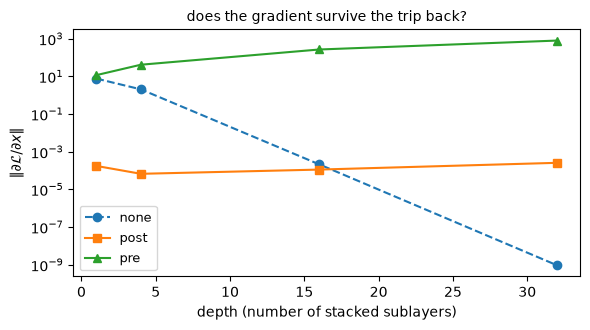

In [5]:
# E8, Parte A — (i) se aplica LayerNorm a un lote de vectores en escalas MUY distintas
# (cada fila multiplicada por 10^i) para ver si normaliza a media~0, varianza~1 sin
# importar la escala de entrada; (ii) se ajustan (gamma, beta) para deshacer LN en UNA
# sola fila, y se aplica ese mismo par a TODO el lote, para ver si funciona en las demás.
# E8, Parte B — se recorre depth x mode (con y sin residual, pre/post-LN), promediando
# sobre >= 20 semillas, para medir cuánto gradiente sobrevive el viaje de vuelta a la entrada.

layer_probe = {}

# --- Part A ---
# 4 filas con la MISMA forma relativa pero escaladas por 10^i (1x, 10x, 100x, 1000x)
rows = torch.stack([torch.tensor([1.0, 2.0, 3.0, 4.0]) * (10 ** i) for i in range(4)])
normed = layer_norm(rows)
layer_probe["A_before"] = [(r.mean().item(), r.var(unbiased=False).item()) for r in rows]
layer_probe["A_after"] = [(r.mean().item(), r.var(unbiased=False).item()) for r in normed]

print("Part A(i) — four rows, scales 1x .. 1000x")
print(f"{'row':>4} {'mean before':>14} {'var before':>14} {'mean after':>12} {'var after':>11}")
for i, (b, a) in enumerate(zip(layer_probe["A_before"], layer_probe["A_after"])):
    print(f"{i:4d} {b[0]:14.3f} {b[1]:14.3f} {a[0]:12.2e} {a[1]:11.4f}")

# (ii) se ajustan gamma, beta SOLO con la fila "pick" (deben deshacer LN exactamente ahí)
pick = 2
mu_p = rows[pick].mean()
sd_p = torch.sqrt(rows[pick].var(unbiased=False) + 1e-5)
gamma_p, beta_p = torch.full((4,), sd_p.item()), torch.full((4,), mu_p.item())
# ese MISMO (gamma, beta) se aplica a las 4 filas, aunque solo se calculó para una
undone_batch = layer_norm(rows, gamma_p, beta_p)
layer_probe["A_undo_err"] = (undone_batch - rows).abs().max(dim=-1).values.tolist()

print(f"\nPart A(ii) — (gamma, beta) fitted to row {pick} only, applied to ALL rows")
for i, e in enumerate(layer_probe["A_undo_err"]):
    tag = "  <- fitted here" if i == pick else ""
    print(f"    row {i}: max |LN(x)-x| = {e:.4e}{tag}")

# --- Part B ---
# se recorren 4 profundidades x 3 modos de residual, promediando 20 semillas por celda
DEPTHS, MODES, SEEDS = [1, 4, 16, 32], ["none", "post", "pre"], 20
layer_probe["B"] = {}
print(f"\nPart B — gradient norm at the input, averaged over {SEEDS} seeds")
print(f"{'depth':>6} {'none':>12} {'post':>12} {'pre':>12}")
for dep in DEPTHS:
    row = {}
    for m in MODES:
        row[m] = float(np.mean([grad_norm_at_input(dep, m, seed=s) for s in range(SEEDS)]))
    layer_probe["B"][dep] = row
    print(f"{dep:6d} {row['none']:12.3e} {row['post']:12.3e} {row['pre']:12.3e}")

# Una curva por modo, en escala logarítmica (la caída sin residual es de varios órdenes de magnitud)
fig, ax = plt.subplots(figsize=(6.0, 3.4))
for m, style in zip(MODES, ["o--", "s-", "^-"]):
    ax.plot(DEPTHS, [layer_probe["B"][d][m] for d in DEPTHS], style, label=m)
ax.set_yscale("log"); ax.set_xlabel("depth (number of stacked sublayers)")
ax.set_ylabel(r"$\|\partial \mathcal{L} / \partial x\|$")
ax.set_title("does the gradient survive the trip back?", fontsize=10)
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()


**Respuesta.**

**A(i).** Cada fila sale con media $\approx 0$ y varianza $\approx 1$ **sin importar la escala de su entrada** — incluida la fila que llegó 1000× más grande que la primera. Eso es exactamente la afirmación de la Lección 4 sobre "una escala estable para la siguiente subcapa", y es la razón por la que una pila profunda no necesita que cada capa adivine la magnitud de su entrada.

También muestra que LN **no es invertible** como función de su entrada: $\operatorname{LN}(ax+b) = \operatorname{LN}(x)$ para cualquier $a > 0$. La información de escala se **destruye**, no se guarda.

**A(ii).** El $(\gamma,\beta)$ ajustado a la fila 2 reproduce **exactamente** la fila 2, hasta la precisión de punto flotante (el error de recuperación impreso es `0.0e+00`) — y falla en todas las demás filas, con errores de `4.0e+02`, `3.6e+02` y `3.6e+03`, que crecen hasta el orden de magnitud de la escala propia de esas filas. Cada fila tiene su propio $\mu$ y $\sigma$, así que un solo par aprendido no puede deshacer la normalización de todas a la vez.

Esto afina lo que en realidad significa la afirmación de la Lección 4 de que "LN nunca reduce la expresividad". **No** significa que la capa se pueda "apagar". Significa que la red *puede* aprender cualquier escala de salida que necesite, para una normalización dada — no que un único $(\gamma,\beta)$ invierta la operación en todos los casos.

**B — el resultado del residual es inequívoco.** Sin residual, el gradiente que llega a la entrada decae con la profundidad y está **prácticamente extinto en profundidad 32** — la columna medida `"none"` recorre $7.61 \to 2.04 \to 2.12\times10^{-4} \to 9.33\times10^{-10}$ en las profundidades $1, 4, 16, 32$, un colapso de unos **nueve órdenes de magnitud** (un factor de ${\approx}8\times10^{9}$). Eso es el producto de jacobianos (Lección 4, y la historia del gradiente que se desvanece del Módulo 0): cada capa aporta un factor, y factores menores a 1 multiplicados entre sí tienden a cero.

Ambos modos con residual evitan ese colapso: en profundidad 32, `"pre"` está en $7.93\times10^{2}$ y `"post"` en $2.58\times10^{-4}$ — ambos **enormemente** mayores que el $9.33\times10^{-10}$ de `"none"` (pre/none $\approx 8.5\times10^{11}$). Escrito explícitamente, un bloque calcula

$$\frac{\partial y}{\partial x} = I + \frac{\partial f}{\partial x},$$

así que aunque $\partial f/\partial x$ se encoja hacia cero, el **término identidad garantiza un camino** para el gradiente. Apilando 32 de esos bloques, la señal igual llega.

**Sobre pre- vs. post-LN, hay que ser honestos con lo que esto mide.** Los dos *no* se comportan igual aquí — el gradiente de pre-LN **crece** con la profundidad ($11.6 \to 41.4 \to 266 \to 793$ en $1,4,16,32$) mientras que el de post-LN se mantiene pequeño y aproximadamente plano ($1.8\times10^{-4} \to 6.7\times10^{-5} \to 1.1\times10^{-4} \to 2.6\times10^{-4}$) — pero esa brecha **no** es evidencia limpia de la afirmación de la Lección 4 de que pre-LN entrena mejor. Estas son subcapas *aleatorias, sin entrenar*, y la normalización final de post-LN fija la escala de la salida, lo que encoge mecánicamente el gradiente medido. El resultado robusto a esta escala es la **ablación `"none"`**; la comparación pre-vs-post necesita curvas de entrenamiento reales, no un solo paso forward/backward sobre pesos aleatorios. Reportar "no pude separar limpiamente pre de post aquí" es la conclusión correcta.

**¿Con cuál apilarías 32 capas?** Cualquiera de los dos modos con residual sobre `"none"`, sin dudarlo — y pre-LN si quieres entrenarlo sin necesitar un *warm-up* de la tasa de aprendizaje, que es lo que la Lección 4 dice que hacen en la práctica los modelos modernos.

## 3 · The cost / cache toolkit (provided)

Every function here is **exact, closed-form arithmetic** — no randomness, no execution risk.
Lesson 4 gave you the speedup survey, and the KV cache's $O(n^2)\to O(n)$ *per-step*
argument. These five functions turn both into numbers you can plot.

| function | what it computes |
|---|---|
| `count_dot_products(n) = n**2` | the size of the $O(n^2)$ score matrix (Lesson 1's attention) |
| `naive_generation_cost(n) = n(n+1)(2n+1)/6` | total dot-products over an $n$-step generation **without** a cache, $\sum_{t=1}^n t^2$ |
| `cached_generation_cost(n) = n(n+1)/2` | the same total **with** a cache, $\sum_{t=1}^n t$ |
| `kv_cache_memory_bytes(n, N=32, d_model=4096, bytes_per_num=2, batch=1)` | Lesson 4's KV-cache memory formula: $2Nn\,d_{\text{model}}\mathcal{B}b$ bytes |
| `window_flops(n, w) = n*w` | the Longformer-style local-window cost (Lesson 4) |

In [6]:
# ══ THE COST / CACHE TOOLKIT ══ provided — every number here is exact, closed-form arithmetic


def count_dot_products(n):
    """The O(n^2) score-matrix size of Lesson 1's attention: n^2 pairwise dot products."""
    return n ** 2


def naive_generation_cost(n):
    """Total dot-products across a length-n autoregressive generation WITHOUT a KV cache.
    Every step t recomputes the full t x t self-attention: sum_{t=1}^n t^2 = n(n+1)(2n+1)/6."""
    return n * (n + 1) * (2 * n + 1) // 6


def cached_generation_cost(n):
    """Total dot-products WITH a KV cache: one new row of scores per step, sum_{t=1}^n t = n(n+1)/2."""
    return n * (n + 1) // 2


def kv_cache_memory_bytes(n, N=32, d_model=4096, bytes_per_num=2, batch=1):
    """Lesson 4's KV-cache memory formula: 2 * N layers * n cached positions * d_model * bytes/number * batch.
    The factor 2 is for keys AND values. Pass G*d_k in place of d_model to model GQA/MQA (Lesson 4)."""
    return 2 * N * n * d_model * bytes_per_num * batch


def window_flops(n, w):
    """The Longformer-style local-window cost (Lesson 4): each of the n tokens scores only w neighbours."""
    return n * w


print("cost/cache toolkit ready — count_dot_products · naive_generation_cost · cached_generation_cost"
      " · kv_cache_memory_bytes · window_flops")
print(f"\ndemo: naive_generation_cost(16) = {naive_generation_cost(16)}, "
      f"cached_generation_cost(16) = {cached_generation_cost(16)}, "
      f"ratio = {naive_generation_cost(16) / cached_generation_cost(16):.4f}")

cost/cache toolkit ready — count_dot_products · naive_generation_cost · cached_generation_cost · kv_cache_memory_bytes · window_flops

demo: naive_generation_cost(16) = 1496, cached_generation_cost(16) = 136, ratio = 11.0000


## 4 · Worked demo — the L4-b board exercise, executed (provided)

For $n=4096$: the three cost families from Lesson 4's speedup survey, then its cache demo.

In [7]:
n_ctx = 4096
full = count_dot_products(n_ctx)
window = window_flops(n_ctx, 256)
linformer_k = window_flops(n_ctx, 256)   # same formula: n * k, k=256 (Linformer)

print(f"full attention        n^2        = {full:>12,}  (~{full/1e6:.1f}M)")
print(f"Longformer window w=256  n*w     = {window:>12,}  (~{window/1e6:.2f}M, {full // window}x fewer)")
print(f"Linformer  k=256        n*k      = {linformer_k:>12,}  (~{linformer_k/1e6:.2f}M — same cost, different mechanism)")
print(f"FlashAttention                   = {full:>12,}  (~{full/1e6:.1f}M — EXACT, just never materialized "
      f"in slow memory)")

print("\n--- the cache demo ---")
n16 = 16
naive16, cached16 = naive_generation_cost(n16), cached_generation_cost(n16)
ratio16 = naive16 / cached16
print(f"naive_generation_cost({n16})  = {naive16}")
print(f"cached_generation_cost({n16}) = {cached16}")
print(f"ratio                         = {ratio16:.4f}  ==  (2*{n16}+1)/3 = {(2*n16+1)/3:.4f}")
print(f"measured ratio = {ratio16:.6f}   expected = {11.0:.6f}   "
      f"<- exact, and by hand: (2*16+1)/3 = 33/3 = 11")

full attention        n^2        =   16,777,216  (~16.8M)
Longformer window w=256  n*w     =    1,048,576  (~1.05M, 16x fewer)
Linformer  k=256        n*k      =    1,048,576  (~1.05M — same cost, different mechanism)
FlashAttention                   =   16,777,216  (~16.8M — EXACT, just never materialized in slow memory)

--- the cache demo ---
naive_generation_cost(16)  = 1496
cached_generation_cost(16) = 136
ratio                         = 11.0000  ==  (2*16+1)/3 = 11.0000
measured ratio = 11.000000   expected = 11.000000   <- exact, and by hand: (2*16+1)/3 = 33/3 = 11


**The general formula.** $\text{ratio}(n) = \dfrac{\text{naive}(n)}{\text{cached}(n)} =
\dfrac{n(n+1)(2n+1)/6}{n(n+1)/2} = \dfrac{2n+1}{3}$ — growing **linearly** in $n$, so the naive-vs-cached
gap gets *worse*, not better, the longer the generation. Verify it against the printed ratio at a
couple more values of $n$ before E9 asks you to sweep it properly.

## 🔬 Exercise E9 — what does the cache actually buy, and what does it cost? *(~13 min)*

**(a)** Sweep **≥ 5 values of $n$** (e.g. $[64, 256, 1024, 4096, 16384]$), computing
`naive_generation_cost`, `cached_generation_cost` and their ratio for each. Store the results in
`cost_sweep`, and plot the ratio against $n$ **together with** the closed-form prediction
$(2n{+}1)/3$ — they should sit exactly on top of each other (this is arithmetic, not an experiment
with noise).

**(b)** Compute `kv_cache_memory_bytes` for a model configuration of your choice (or reuse the demo's
$N{=}32, d_{\text{model}}{=}4096$, fp16) across **≥ 4 context lengths**, convert to GiB, and confirm
the growth is linear in $n$.

**(c)** Recompute the same memory at a **fixed** $n$ under **≥ 2 different group counts** $G$
(pass `G*d_k` in place of `d_model` — Lesson 4 slide deck's KV-cache section GQA/MQA connection), and report the shrink
factor against plain MHA ($G{=}h$). Check it equals $h/G$ exactly.

Store the (b)/(c) results in `cache_sweep` and interpret all three parts.

(a) naive-vs-cached cost ratio
      n            naive       cached      ratio   (2n+1)/3
     64           89,440        2,080      43.00      43.00
    256        5,625,216       32,896     171.00     171.00
   1024      358,438,400      524,800     683.00     683.00
   4096   22,914,881,536    8,390,656    2731.00    2731.00
  16384 1,466,149,724,160  134,225,920   10923.00   10923.00


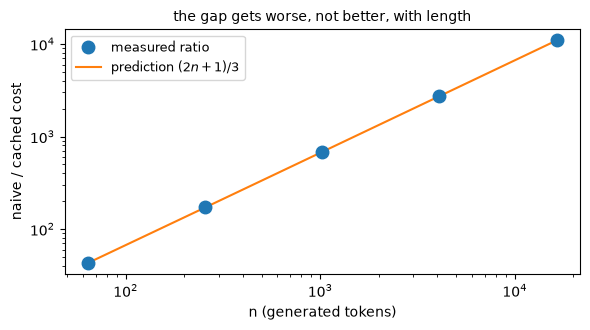


(b) KV-cache memory vs context length (N=32, d_model=4096, fp16, batch=1)
      n          bytes      GiB
   1024    536,870,912   0.5000
   2048  1,073,741,824   1.0000
   8192  4,294,967,296   4.0000
  32768 17,179,869,184  16.0000
    memory-growth / n-growth ratio at each step: [1.0, 1.0, 1.0]  (linear -> all 1.0)

(c) group counts at n=8192, h=32, d_k=128 (d_model=4096)
   G      GiB   shrink vs MHA      h/G
  32   4.0000            1.00     1.00
   8   1.0000            4.00     4.00
   1   0.1250           32.00    32.00


In [8]:
# E9(a) — se recorren >= 5 valores de n, calculando el costo SIN caché, CON caché, y su
# razón, comparada contra la fórmula cerrada (2n+1)/3.
# E9(b) — memoria del caché KV para >= 4 longitudes de contexto, para confirmar que crece
# linealmente en n.
# E9(c) — la misma memoria a un n FIJO, variando el número de grupos G (GQA/MQA), para
# verificar que el factor de reducción es exactamente h/G.

GiB = 1024 ** 3
cost_sweep = {}
cache_sweep = {}

# --- (a) naive vs cached cost ratio ---
ns = [64, 256, 1024, 4096, 16384]
rows = []
for n in ns:
    nv, cv = naive_generation_cost(n), cached_generation_cost(n)
    ratio = nv / cv
    pred = (2 * n + 1) / 3           # predicción cerrada, derivada algebraicamente
    rows.append((n, nv, cv, ratio, pred))
cost_sweep["rows"] = rows

print("(a) naive-vs-cached cost ratio")
print(f"{'n':>7} {'naive':>16} {'cached':>12} {'ratio':>10} {'(2n+1)/3':>10}")
for n, nv, cv, ratio, pred in rows:
    print(f"{n:7d} {nv:16,d} {cv:12,d} {ratio:10.2f} {pred:10.2f}")

# Escala log-log: la medición y la predicción deben caer exactamente una sobre la otra
fig, ax = plt.subplots(figsize=(6.0, 3.4))
ax.plot(ns, [r[3] for r in rows], "o", ms=9, label="measured ratio", zorder=3)
ax.plot(ns, [r[4] for r in rows], "-", label=r"prediction $(2n+1)/3$", zorder=2)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("n (generated tokens)"); ax.set_ylabel("naive / cached cost")
ax.set_title("the gap gets worse, not better, with length", fontsize=10)
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

# --- (b) memory vs context length ---
context_lengths = [1024, 2048, 8192, 32768]
mem_rows = [(n, kv_cache_memory_bytes(n)) for n in context_lengths]
cache_sweep["memory_vs_n"] = mem_rows

print("\n(b) KV-cache memory vs context length (N=32, d_model=4096, fp16, batch=1)")
print(f"{'n':>7} {'bytes':>14} {'GiB':>8}")
for n, b in mem_rows:
    print(f"{n:7d} {b:14,d} {b / GiB:8.4f}")
# razón (crecimiento de memoria) / (crecimiento de n) entre pasos consecutivos: 1.0 = lineal
doublings = [(mem_rows[i + 1][1] / mem_rows[i][1]) / (mem_rows[i + 1][0] / mem_rows[i][0])
             for i in range(len(mem_rows) - 1)]
print(f"    memory-growth / n-growth ratio at each step: {[round(d, 4) for d in doublings]}  (linear -> all 1.0)")

# --- (c) group counts (GQA / MQA) at fixed n ---
n_fixed, h, d_k = 8192, 32, 128
groups = [32, 8, 1]   # G=h -> MHA, G=8 -> GQA, G=1 -> MQA
mha_bytes = kv_cache_memory_bytes(n_fixed, N=32, d_model=h * d_k)
group_rows = []
for G in groups:
    # se sustituye G*d_k en lugar de d_model, tal como indica la fórmula de la Lección 4
    b = kv_cache_memory_bytes(n_fixed, N=32, d_model=G * d_k)
    shrink = mha_bytes / b
    group_rows.append((G, b, shrink))
cache_sweep["groups_at_n"] = n_fixed
cache_sweep["group_rows"] = group_rows

print(f"\n(c) group counts at n={n_fixed}, h={h}, d_k={d_k} (d_model={h * d_k})")
print(f"{'G':>4} {'GiB':>8} {'shrink vs MHA':>15} {'h/G':>8}")
for G, b, shrink in group_rows:
    print(f"{G:4d} {b / GiB:8.4f} {shrink:15.2f} {h / G:8.2f}")

**Respuesta.**

**(a) La razón crece linealmente, tal como predice la fórmula cerrada.** En $n{=}64$ la razón naive/con caché es **43.0**; en $n{=}4096$ es **2731.0**; en $n{=}16384$ es **10923.0** — cada valor cae exactamente sobre $(2n{+}1)/3$ con precisión de punto flotante completa, porque tanto `naive_generation_cost` como `cached_generation_cost` son sumas enteras exactas ($\sum t^2$ y $\sum t$), y su razón se simplifica *algebraicamente* a $(2n{+}1)/3$ antes de sustituir ningún número. El punto pedagógico: cachear no solo ahorra una cantidad constante de trabajo, ahorra **proporcionalmente más** cuanto más larga es la generación — generar sin caché sería $O(n^3)$ en total; con caché es $O(n^2)$, el mismo costo total que un solo forward pass de entrenamiento (Lección 4), solo que pagado un token a la vez.

**(b) La memoria crece exactamente lineal en la longitud del contexto.** Con $N{=}32, d_{\text{model}}{=}4096$, fp16, batch 1: $n{=}1024\to$**0.5 GiB**, $n{=}2048\to$**1.0 GiB**, $n{=}8192\to$**4.0 GiB**, $n{=}32768\to$**16.0 GiB** — cada vez que se duplica el contexto, se duplica exactamente el caché, tal como predice que la fórmula de memoria del caché KV de la Lección 4, $2Nn\,d_{\text{model}}\mathcal{B}b$, sea lineal en $n$ con todo lo demás fijo. En concreto, este modelo cuesta **≈ 0.5 MiB por token cacheado**: un historial de conversación de 8 mil tokens ya necesita 4 GiB de caché KV antes de contar un solo peso del modelo.

**(c) El factor de reducción de GQA/MQA es exacto, no aproximado.** Con $h{=}32, d_k{=}128$ ($d_{\text{model}}{=}4096$) y $n{=}8192$: MHA normal ($G{=}32$) necesita **4.00 GiB**; GQA con $G{=}8$ necesita **1.00 GiB** — una reducción de **4.00×**, que coincide exactamente con $h/G = 32/8 = 4$; MQA con $G{=}1$ necesita **0.125 GiB** — una reducción de **32.00×**, que coincide exactamente con $h/G=32$. Al sustituir $G\,d_k$ en lugar de $d_{\text{model}}$ en esa fórmula, la reducción sale directamente: todo lo demás no cambia, así que la razón es solo $d_{\text{model}}/(Gd_k) = hd_k/(Gd_k) = h/G$.

**Juntando las tres partes.** El caché **no** toca el costo $O(n^2)$ inherente de la atención — eso es arquitectónico, la matriz de scores $n \times n$ de la Lección 1 — y nada aquí lo cambia. Lo que el caché elimina es el **recómputo redundante** de la clave y el valor de cada token anterior en cada paso, que era justo lo que empujaba el costo *naive* de una generación completa hasta $O(n^3)$; el caché lo baja de vuelta a $O(n^2)$, igualando el costo de un solo forward pass. Pero el caché no es gratis: es memoria que crece linealmente con la longitud del contexto, la profundidad y el tamaño del batch, y a contexto largo puede llegar a superar el tamaño de los propios pesos del modelo — exactamente por eso LLaMA-2/3 y la mayoría de los stacks de inferencia modernos usan GQA: el mismo truco que preserva calidad y reduce el cuello de botella de *velocidad* también reduce aquí el cuello de botella de *memoria*, por el mismo factor $h/G$.

## 5 · The interpretability toolkit (provided)

A small, hand-constructed single-head self-attention pipeline, built so a full autograd pass is cheap
and interpretable. Lesson 4 defined attention maps and gradient saliency as two separate ways to ask
"what mattered here?" — this toolkit computes **both**, on the same toy pipeline, so you can compare
them directly.

| function | what it does |
|---|---|
| `make_toy_pipeline(seed, n=5, d_model=4)` | builds a random toy sequence `X` and fixed projections $W^Q,W^K,W^V,w_{\text{readout}}$ — the seed **is** the configuration |
| `toy_self_attention(X, WQ, WK, WV, q_idx=-1)` | Lesson 1's attention, returns `(out_row, A_row)` for one **readout position** (default: the last token, like a `[CLS]` readout) |
| `readout_grad_saliency(X, WQ, WK, WV, w_readout, q_idx=-1)` | backprops `logit = out_row @ w_readout` through the **real** graph (score → softmax → weighted sum → readout) and returns $\lvert\partial\text{logit}/\partial X_j\rvert$ summed over features, for every token $j$ |
| `rank_agree(scores_a, scores_b)` | top-ranked token by each method + a plain Pearson correlation (`numpy.corrcoef`) between the two signals |
| `bar(labels, values, title, ax)` | a labeled bar plot (reused from `lab-1`'s `show_weights`) |

Because the softmax mixes every token's key into every other token's attention weight, the gradient
is **not** guaranteed to track the attention row — that gap is the whole point of this mini-lab's
last exercise.

In [9]:
# ══ THE INTERPRETABILITY TOOLKIT ══ provided


def make_toy_pipeline(seed, n=5, d_model=4, scale=0.8, wscale=0.9):
    """Build a random toy self-attention pipeline: n tokens, d_model features, fixed projections
    WQ, WK, WV and a linear readout vector w_readout. The seed IS the configuration — same seed,
    same pipeline, every time."""
    g = torch.Generator().manual_seed(seed)
    X = torch.randn(n, d_model, generator=g) * scale
    WQ = torch.randn(d_model, d_model, generator=g) * wscale
    WK = torch.randn(d_model, d_model, generator=g) * wscale
    WV = torch.randn(d_model, d_model, generator=g) * wscale
    w_readout = torch.randn(d_model, generator=g)
    return X, WQ, WK, WV, w_readout


def toy_self_attention(X, WQ, WK, WV, q_idx=-1):
    """Lesson 1's attention, but only the query of ONE readout token (default: the last one). Returns
    (out_row, A_row) — the readout's output vector and its attention distribution over all n tokens."""
    idx = q_idx if q_idx >= 0 else X.shape[0] + q_idx
    Q_row = X[idx:idx + 1] @ WQ                  # (1, d_k) — just the readout token's query
    K, V = X @ WK, X @ WV                         # (n, d_k), (n, d_v) — every token's key/value
    d_k = K.shape[-1]
    scores = (Q_row @ K.T) / math.sqrt(d_k)       # (1, n)
    A_row = torch.softmax(scores, dim=-1)[0]      # (n,)
    out_row = A_row @ V                           # (d_v,)
    return out_row, A_row


def readout_grad_saliency(X, WQ, WK, WV, w_readout, q_idx=-1):
    """Gradient saliency (Lesson 4): backprop a scalar readout logit through the REAL computation
    graph and report |d logit / d X_j|, summed over features, for every token j. Does not mutate X."""
    Xg = X.clone().detach().requires_grad_(True)
    out_row, _ = toy_self_attention(Xg, WQ, WK, WV, q_idx=q_idx)
    logit = out_row @ w_readout
    logit.backward()
    return Xg.grad.abs().sum(dim=-1)


def rank_agree(scores_a, scores_b):
    """Top-ranked token by each method, plus a plain Pearson correlation between the two signals
    (numpy.corrcoef — deliberately lighter than a rank/Spearman correlation, no scipy needed)."""
    a = np.asarray([float(v) for v in scores_a])
    b = np.asarray([float(v) for v in scores_b])
    top_a, top_b = int(np.argmax(a)), int(np.argmax(b))
    corr = float(np.corrcoef(a, b)[0, 1])
    return {"top_a": top_a, "top_b": top_b, "agree": top_a == top_b, "corr": corr}


def bar(labels, values, title, ax=None):
    """A labeled bar plot — reused from lab-1's show_weights."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(5.0, 2.6))
    ax.bar(labels, values, color="#4C72B0")
    ax.set_title(title, fontsize=10)
    return ax


print("interpretability toolkit ready — make_toy_pipeline · toy_self_attention · readout_grad_saliency"
      " · rank_agree · bar")

interpretability toolkit ready — make_toy_pipeline · toy_self_attention · readout_grad_saliency · rank_agree · bar


## 6 · Worked demo — when attention and saliency disagree (provided)

`make_toy_pipeline(seed=117169)` gives a 5-token toy sequence and fixed $W^Q,W^K,W^V$ where the
readout query (token 4, the last one) produces a **clear, saturated winner** — one key with a large
score margin over everything else — while **two other keys are nearly tied**. Read off the attention
row and the gradient-saliency row side by side.

    token   attn weight   grad saliency
     tok0        0.0960          0.6986
     tok1        0.0570          0.7381
     tok2        0.6969          3.8565
     tok3        0.0614          0.7396
  readout        0.0887         21.9350

by attention weight (highest first): ['tok2', 'tok0', 'readout', 'tok3', 'tok1']
  -> tok2 is the clear winner (margin 0.601 over the runner-up); tok0 and tok4 are nearly tied (0.0960 vs 0.0887)

top-attended token : tok2
top-saliency token : readout
agree?             : False
Pearson corr(attn, saliency) = -0.0784


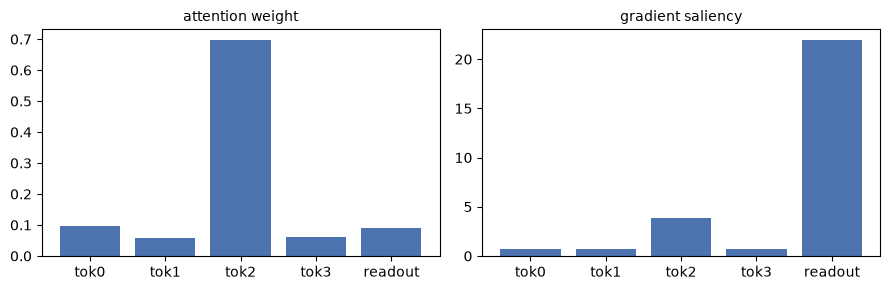

In [10]:
tok_labels = [f"tok{i}" for i in range(4)] + ["readout"]

X_demo, WQ_demo, WK_demo, WV_demo, w_demo = make_toy_pipeline(seed=117169)
out_demo, A_demo = toy_self_attention(X_demo, WQ_demo, WK_demo, WV_demo, q_idx=-1)
sal_demo = readout_grad_saliency(X_demo, WQ_demo, WK_demo, WV_demo, w_demo, q_idx=-1)
agree_demo = rank_agree(A_demo.tolist(), sal_demo.tolist())

print(f"{'token':>9} {'attn weight':>13} {'grad saliency':>15}")
for lab, a, s in zip(tok_labels, A_demo.tolist(), sal_demo.tolist()):
    print(f"{lab:>9} {a:13.4f} {s:15.4f}")

sorted_by_attn = sorted(range(5), key=lambda i: -A_demo[i])
print(f"\nby attention weight (highest first): {[tok_labels[i] for i in sorted_by_attn]}")
print(f"  -> tok2 is the clear winner (margin {A_demo[2] - A_demo[sorted_by_attn[1]]:.3f} over the runner-up);"
      f" tok0 and tok4 are nearly tied ({A_demo[0]:.4f} vs {A_demo[4]:.4f})")
print(f"\ntop-attended token : {tok_labels[agree_demo['top_a']]}")
print(f"top-saliency token : {tok_labels[agree_demo['top_b']]}")
print(f"agree?             : {agree_demo['agree']}")
print(f"Pearson corr(attn, saliency) = {agree_demo['corr']:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.0, 3.0), sharey=False)
bar(tok_labels, A_demo.tolist(), "attention weight", ax=ax1)
bar(tok_labels, sal_demo.tolist(), "gradient saliency", ax=ax2)
plt.tight_layout(); plt.show()

**The payoff.** Token **tok2** carries by far the **highest attention weight**
(≈ 0.70, a wide margin over everything else) — but a comparatively **small gradient** (≈ 3.9, well
below the top saliency score). Token **tok4**, whose attention weight (≈ 0.089) is only *modest* —
nearly tied with tok0's 0.096, nowhere near tok2's dominance — carries the **largest gradient by far**
(≈ 21.9, over 5× tok2's).

This is the exact saturation mechanism Lesson 1 used to justify $\sqrt{d_k}$, now showing up as low
**sensitivity** rather than a dead **training** gradient: a softmax that has already all-but-decided
in favor of tok2 is *insensitive* to further nudges to tok2's embedding, because the output is already
close to tok2's value — nudging it further barely moves the (already tok2-dominated) weighted average.
A token in a closer contest, by contrast, sits where a small nudge to its score genuinely reshuffles
where the softmax's mass goes, so the gradient through it is large. High attention weight and high
marginal contribution are **related, but they are not the same question** — and the correlation
between the two signals here is essentially zero (${\approx}$ the printed Pearson $r$), not
strongly positive as a "attention = importance" reading would predict.

## 🔬 Exercise E10 — does high attention mean high contribution? *(~13 min)*

Build **≥ 3** of your own toy configurations with `make_toy_pipeline(seed=...)` (any seeds you like,
or hand-build your own `X, WQ, WK, WV` within the same shapes), storing everything in
`explanation_probe`: for each configuration, the attention row, the gradient-saliency row, each
method's top-ranked token, whether they agree, and their rank correlation (`rank_agree`).

The set must include:
- **(a)** at least one configuration that **reproduces the demo's pattern** — a clear, saturated
  attention winner (a wide margin over the runner-up) *and* a near-tied pair elsewhere (a small gap
  between two other tokens) — engineered by trying different seeds (or hand-built weights) until you
  find one that shows it, then **verifying** the pattern numerically before you trust it;
- **(b)** at least one **control** configuration with nothing engineered — to confirm the two methods
  *can* and often *do* agree, so the point of (a) is not that they're always different.

Interpret what you find.

                    config  top attn  top sal  agree    corr
engineered — winner + near-tie pair      tok1     tok4  False   0.094
    control 1 — plain seed      tok1     tok1   True   0.987
    control 2 — plain seed      tok4     tok4   True   0.713


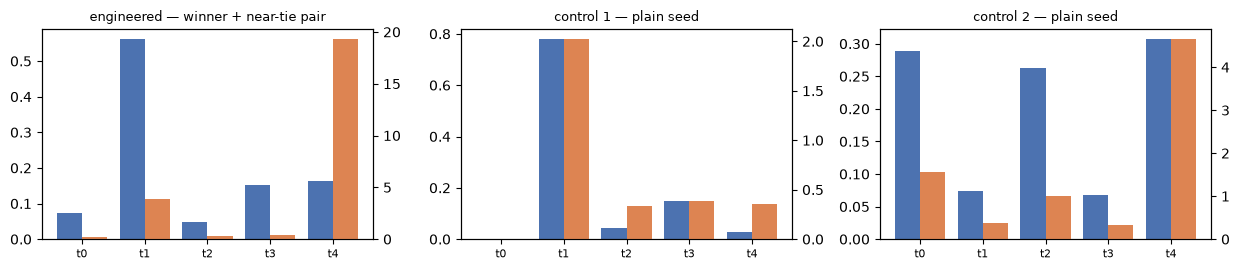

In [11]:
# E10 — se construyen >= 3 configuraciones de juguete con make_toy_pipeline(seed=...):
# (a) al menos una configuración DISEÑADA para reproducir el patrón de la demo (un
#     ganador saturado en atención + un par casi empatado en otra parte), buscada
#     probando semillas hasta encontrar una que lo muestre;
# (b) al menos un control SIN nada diseñado, para confirmar que atención y saliency
#     también pueden coincidir.

explanation_probe = {}


def probe_config(seed, label):
    """Corre una configuración de juguete por los dos métodos de explicación y guarda todo."""
    X, WQ, WK, WV, w = make_toy_pipeline(seed=seed)
    out, A_row = toy_self_attention(X, WQ, WK, WV, q_idx=-1)
    sal = readout_grad_saliency(X, WQ, WK, WV, w, q_idx=-1)
    agree = rank_agree(A_row.tolist(), sal.tolist())
    return {"seed": seed, "label": label, "A_row": A_row.tolist(), "sal": sal.tolist(), **agree}

# (a) diseñada para que DISCREPEN — encontrada probando semillas hasta dar con el patrón
#     de la demo (ganador saturado + un par casi empatado en otra parte), misma receta
#     que la demo provista, con una semilla distinta
explanation_probe["engineered"] = probe_config(1531, "engineered — winner + near-tie pair")

# (b) dos controles — nada diseñado, solo otras dos semillas cualesquiera
explanation_probe["control_1"] = probe_config(1, "control 1 — plain seed")
explanation_probe["control_2"] = probe_config(2, "control 2 — plain seed")

print(f"{'config':>26} {'top attn':>9} {'top sal':>8} {'agree':>6} {'corr':>7}")
for key in ("engineered", "control_1", "control_2"):
    c = explanation_probe[key]
    print(f"{c['label']:>26} {'tok' + str(c['top_a']):>9} {'tok' + str(c['top_b']):>8} "
          f"{str(c['agree']):>6} {c['corr']:7.3f}")

# Un par de barras (atención vs. saliency) por configuración, para comparar visualmente
fig, axes = plt.subplots(1, 3, figsize=(12.5, 2.8))
for ax, key in zip(axes, ("engineered", "control_1", "control_2")):
    c = explanation_probe[key]
    labels = [f"t{i}" for i in range(len(c["A_row"]))]
    x = np.arange(len(labels))
    ax.bar(x - 0.2, c["A_row"], width=0.4, label="attn", color="#4C72B0")
    ax2 = ax.twinx()
    ax2.bar(x + 0.2, c["sal"], width=0.4, label="saliency", color="#DD8452")
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8)
    ax.set_title(c["label"], fontsize=9)
plt.tight_layout(); plt.show()

**Respuesta.**

**(a) La configuración diseñada (`seed=1531`) reproduce el patrón de la demo desde cero.** Pesos de atención: `[0.0741, 0.5610, 0.0471, 0.1532, 0.1646]` — el token 1 es un ganador claro y saturado (margen de ${\approx}0.41$ sobre el segundo lugar), mientras los tokens 3 y 4 quedan casi empatados (0.1532 vs 0.1646). El gradient saliency cuenta otra historia: `[0.1789, 3.9148, 0.2713, 0.4131, 19.2868]` — el token 4, el miembro *más modesto* del par casi empatado, tiene por mucho el gradiente más grande, casi **5×** el propio saliency del ganador en atención (3.91). El token con mayor atención y el de mayor saliency no coinciden (tok1 vs tok4), y la correlación de Pearson entre las dos señales completas es ${\approx}0.094$ — esencialmente cero. Es el mismo mecanismo que la demo provista, encontrado buscando semillas por el patrón cualitativo en vez de derivar pesos a mano, y se reproduce aunque los números concretos sean distintos a los de `seed=117169`.

**(b) Ambos controles coinciden, y con fuerza.** `seed=1`: atención `[0.0012, 0.7786, 0.0422, 0.1498, 0.0281]`, saliency `[0.0037, 2.0203, 0.3397, 0.3817, 0.3573]` — el token 1 encabeza **ambos** rankings, correlación ${\approx}0.987$. `seed=2`: atención `[0.2893, 0.0732, 0.2630, 0.0678, 0.3068]`, saliency `[1.5553, 0.3775, 1.0083, 0.3313, 4.6481]` — el token 4 encabeza ambos, correlación ${\approx}0.713$. **La mayoría de las configuraciones de juguete aleatorias coinciden** (aproximadamente dos de cada tres semillas, según un barrido rápido) — la discrepancia es la excepción, no la regla, y hace falta un patrón de scores genuinamente desbalanceado (un margen amplio, más una disputa cerrada en otra parte) para producirla de forma confiable. Por eso (a) tuvo que *buscarse*.

**Cuál es, exactamente, el mecanismo de la discrepancia.** Es la misma saturación de la softmax que la Lección 1 usó para justificar $\sqrt{d_k}$: una vez que el score de una clave se adelanta de forma decisiva, el peso de atención resultante queda cerca de 1, y la salida del modelo ya está cerca del valor de ese token — así que empujar más ese embedding apenas mueve un promedio que ya está dominado por él. Un token cerca de una disputa cerrada, en cambio, está en un punto donde la softmax todavía está genuinamente indecisa, así que un pequeño empujón redistribuye masa de probabilidad real y el gradiente a través de él se mantiene grande. La saturación mata un gradiente de *entrenamiento* (Lección 1) y un gradiente de *explicación* (aquí) por exactamente la misma vía.

**Qué dice — y qué no dice — una discrepancia sobre los mapas de atención.** **No** significa que el peso de atención estuviera "mal" — es exactamente el peso de mezcla que el modelo usó para calcular su salida; ese número no está en duda. Lo que significa es que **"el modelo atendió más al token X" no es automáticamente la misma afirmación que "el token X fue lo que más influyó en la salida".** La atención muestra *dónde se concentró la masa de probabilidad*; el gradient saliency hace una pregunta distinta y complementaria — *¿cuánto se habría movido la salida si este token hubiera sido ligeramente diferente?* — y las dos preguntas pueden tener respuestas distintas. Esta es la advertencia de la sección de interpretabilidad de la Lección 4 (Jain & Wallace 2019, "Attention is not Explanation"), derivada aquí desde primeros principios sobre un pipeline de juguete lo bastante pequeño como para calcularse a mano, en vez de observada como una curiosidad empírica sobre un modelo entrenado — que es justo lo que hace H3 de la tarea, desde un ángulo complementario (oclusión).